In [7]:
import torch

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cpu


In [8]:
!pip install -q torch torchvision scikit-learn matplotlib seaborn pillow tqdm

In [9]:
import os
import zipfile
import random
import shutil
import json
import copy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [10]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
DRIVE_ROOT = "/content/drive/MyDrive"

zip_files = []

for root, dirs, files in os.walk(DRIVE_ROOT):

    for file in files:

        if file.lower().endswith(".zip"):

            zip_files.append(
                os.path.join(root, file)
            )

print("ZIP files found:\n")

for path in zip_files:
    print(path)

ZIP files found:

/content/drive/MyDrive/image dataset.zip
/content/drive/MyDrive/AIML DATASET/barack obama phoots - Google Search/barack obama phoots - Google Search.zip
/content/drive/MyDrive/AIML DATASET/trump - Google Search/trump - Google Search.zip
/content/drive/MyDrive/AIML DATASET/elon musk imnages - Google Search/elon musk imnages - Google Search.zip


In [12]:
ZIP_PATH = None

for path in zip_files:

    if "image dataset" in os.path.basename(path).lower():

        ZIP_PATH = path
        break

print("Selected ZIP:")
print(ZIP_PATH)

Selected ZIP:
/content/drive/MyDrive/image dataset.zip


In [13]:
if ZIP_PATH is None:
    raise FileNotFoundError(
        "Could not find image dataset.zip in Google Drive."
    )

print("ZIP found:", ZIP_PATH)
print(
    "Size:",
    round(os.path.getsize(ZIP_PATH) / (1024**3), 2),
    "GB"
)

ZIP found: /content/drive/MyDrive/image dataset.zip
Size: 1.68 GB


In [14]:
EXTRACT_DIR = "/content/deepfake_dataset"

os.makedirs(
    EXTRACT_DIR,
    exist_ok=True
)

print("Extracting dataset...")

with zipfile.ZipFile(
    ZIP_PATH,
    "r"
) as zip_ref:

    zip_ref.extractall(
        EXTRACT_DIR
    )

print("Extraction completed.")

Extracting dataset...
Extraction completed.


In [15]:
for root, dirs, files in os.walk(EXTRACT_DIR):

    level = root.replace(
        EXTRACT_DIR,
        ""
    ).count(os.sep)

    if level <= 2:

        print(
            "  " * level +
            os.path.basename(root) +
            "/"
        )

        for file in files[:5]:

            print(
                "  " * (level + 1) +
                file
            )

deepfake_dataset/
  Dataset/
    Validation/
    Test/
    Train/


In [16]:
def find_folder(parent, folder_name):

    for root, dirs, files in os.walk(parent):

        for d in dirs:

            if d.lower() == folder_name.lower():

                return os.path.join(root, d)

    return None


TRAIN_DIR = find_folder(
    EXTRACT_DIR,
    "train"
)

VAL_DIR = find_folder(
    EXTRACT_DIR,
    "validation"
)

if VAL_DIR is None:
    VAL_DIR = find_folder(
        EXTRACT_DIR,
        "val"
    )

TEST_DIR = find_folder(
    EXTRACT_DIR,
    "test"
)

print("TRAIN:", TRAIN_DIR)
print("VAL:", VAL_DIR)
print("TEST:", TEST_DIR)

TRAIN: /content/deepfake_dataset/Dataset/Train
VAL: /content/deepfake_dataset/Dataset/Validation
TEST: /content/deepfake_dataset/Dataset/Test


In [17]:
print(
    "\nTRAIN folders:",
    os.listdir(TRAIN_DIR)
)

print(
    "VAL folders:",
    os.listdir(VAL_DIR)
)

print(
    "TEST folders:",
    os.listdir(TEST_DIR)
)


TRAIN folders: ['Fake', 'Real']
VAL folders: ['Fake', 'Real']
TEST folders: ['Fake', 'Real']


In [18]:
def count_images(folder):

    count = 0

    for root, dirs, files in os.walk(folder):

        for file in files:

            if file.lower().endswith(
                (".jpg", ".jpeg", ".png", ".webp")
            ):

                count += 1

    return count


print(
    "Training images:",
    count_images(TRAIN_DIR)
)

print(
    "Validation images:",
    count_images(VAL_DIR)
)

print(
    "Test images:",
    count_images(TEST_DIR)
)

Training images: 140002
Validation images: 39428
Test images: 10905


In [19]:
train_transform = transforms.Compose([

    transforms.Resize((128, 128)),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomRotation(
        10
    ),

    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])
test_transform = transforms.Compose([

    transforms.Resize((128, 128)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [20]:
train_dataset = datasets.ImageFolder(
    TRAIN_DIR,
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    VAL_DIR,
    transform=test_transform
)

test_dataset = datasets.ImageFolder(
    TEST_DIR,
    transform=test_transform
)

In [21]:
print(
    "Classes:",
    train_dataset.classes
)

print(
    "Class mapping:",
    train_dataset.class_to_idx
)

Classes: ['Fake', 'Real']
Class mapping: {'Fake': 0, 'Real': 1}


In [22]:
BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


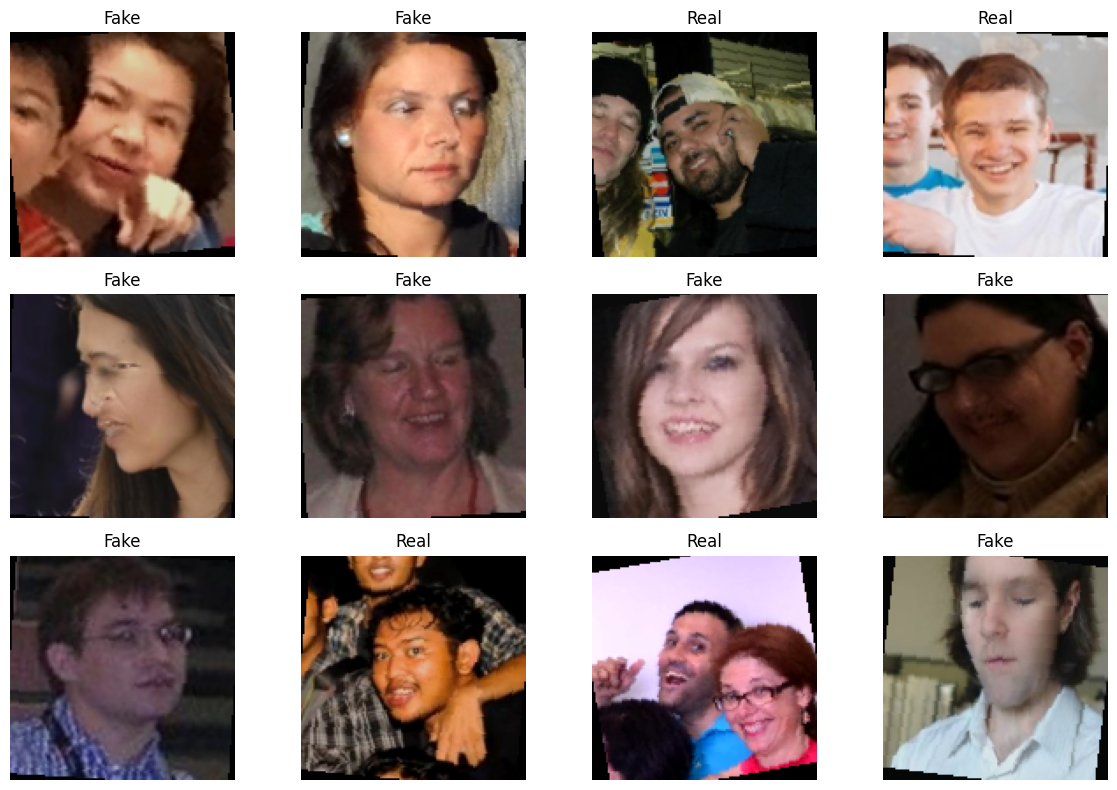

In [23]:
images, labels = next(
    iter(train_loader)
)

plt.figure(figsize=(12, 8))

for i in range(12):

    plt.subplot(3, 4, i + 1)

    image = images[i].permute(
        1, 2, 0
    ).numpy()

    image = (
        image * np.array(
            [0.229, 0.224, 0.225]
        )
        + np.array(
            [0.485, 0.456, 0.406]
        )
    )

    image = np.clip(
        image,
        0,
        1
    )

    plt.imshow(image)

    plt.title(
        train_dataset.classes[
            labels[i].item()
        ]
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [24]:
class DeepfakeCNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.features = nn.Sequential(

            # Block 1
            nn.Conv2d(
                3,
                32,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(32),

            nn.ReLU(),

            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(64),

            nn.ReLU(),

            nn.MaxPool2d(2),

            # Block 3
            nn.Conv2d(
                64,
                128,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(128),

            nn.ReLU(),

            nn.MaxPool2d(2),

            # Block 4
            nn.Conv2d(
                128,
                256,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(256),

            nn.ReLU(),

            nn.MaxPool2d(2)
        )

        self.pool = nn.AdaptiveAvgPool2d(
            (1, 1)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                256,
                128
            ),

            nn.ReLU(),

            nn.Dropout(
                0.5
            ),

            nn.Linear(
                128,
                2
            )
        )


    def forward(self, x):

        x = self.features(x)

        x = self.pool(x)

        x = self.classifier(x)

        return x

In [25]:
model = DeepfakeCNN()

model = model.to(device)

print(model)

DeepfakeCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=Tru

In [26]:
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(
    "Total parameters:",
    f"{total_params:,}"
)

print(
    "Trainable parameters:",
    f"{trainable_params:,}"
)

Total parameters: 422,530
Trainable parameters: 422,530


In [27]:
criterion = nn.CrossEntropyLoss()

In [28]:
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [29]:
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

In [ ]:
EPOCHS = 15
#FOR NOW THE EPOCHS=2 TO SAV TIME BUT MODEL IS TRAINED FOR 15 EPOCHS
#EPOCHS = 2

best_val_accuracy = 0.0

MODEL_PATH = "/content/deepfake_cnn_best.pth"

history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

In [31]:
for epoch in range(EPOCHS):

    # =========================
    # TRAINING
    # =========================

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    progress_bar = tqdm(
        train_loader,
        desc=f"Epoch {epoch + 1}/{EPOCHS}"
    )

    for images, labels in progress_bar:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        # Reset gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(
            outputs,
            labels
        )

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        running_loss += (
            loss.item()
            * images.size(0)
        )

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

        progress_bar.set_postfix(
            loss=loss.item()
        )

    train_loss = (
        running_loss / total
    )

    train_accuracy = (
        correct / total
    ) * 100


    # =========================
    # VALIDATION
    # =========================

    model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            val_running_loss += (
                loss.item()
                * images.size(0)
            )

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            val_correct += (
                predictions == labels
            ).sum().item()

            val_total += labels.size(0)

    val_loss = (
        val_running_loss /
        val_total
    )

    val_accuracy = (
        val_correct /
        val_total
    ) * 100


    # Learning-rate adjustment

    scheduler.step(
        val_accuracy
    )


    # Save history

    history["train_loss"].append(
        train_loss
    )

    history["train_accuracy"].append(
        train_accuracy
    )

    history["val_loss"].append(
        val_loss
    )

    history["val_accuracy"].append(
        val_accuracy
    )


    print(
        f"\nEpoch {epoch + 1}/{EPOCHS}"
    )

    print(
        f"Train Loss: {train_loss:.4f}"
    )

    print(
        f"Train Accuracy: {train_accuracy:.2f}%"
    )

    print(
        f"Validation Loss: {val_loss:.4f}"
    )

    print(
        f"Validation Accuracy: {val_accuracy:.2f}%"
    )


    # =========================
    # SAVE BEST MODEL
    # =========================

    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        torch.save(
            {
                "model_state_dict":
                    model.state_dict(),

                "class_to_idx":
                    train_dataset.class_to_idx,

                "input_size": 128
            },
            MODEL_PATH
        )

        print(
            "✓ Best model saved!"
        )

Epoch 1/10:   0%|          | 0/2188 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    history["train_accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy (%)")

plt.title(
    "CNN Training vs Validation Accuracy"
)

plt.legend()

plt.grid()

plt.show()

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    history["train_loss"],
    label="Training Loss"
)

plt.plot(
    history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title(
    "CNN Training vs Validation Loss"
)

plt.legend()

plt.grid()

plt.show()

In [ ]:
checkpoint = torch.load(
    MODEL_PATH,
    map_location=device
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model = model.to(device)

model.eval()

print(
    "Best validation accuracy:",
    best_val_accuracy
)

In [ ]:
y_true = []
y_pred = []
y_prob = []

model.eval()

with torch.no_grad():

    for images, labels in tqdm(
        test_loader,
        desc="Testing"
    ):

        images = images.to(
            device
        )

        outputs = model(
            images
        )

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        y_true.extend(
            labels.numpy()
        )

        y_pred.extend(
            predictions.cpu().numpy()
        )

        # Probability of REAL class
        y_prob.extend(
            probabilities[:, 1]
            .cpu()
            .numpy()
        )

In [1]:
accuracy = accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    zero_division=0
)

auc = roc_auc_score(
    y_true,
    y_prob
)

print(
    f"Accuracy  : {accuracy * 100:.2f}%"
)

print(
    f"Precision : {precision * 100:.2f}%"
)

print(
    f"Recall    : {recall * 100:.2f}%"
)

print(
    f"F1 Score  : {f1 * 100:.2f}%"
)

print(
    f"ROC-AUC   : {auc:.4f}"
)

NameError: name 'accuracy_score' is not defined

In [ ]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "Fake",
            "Real"
        ],
        zero_division=0
    )
)

In [ ]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(
    figsize=(7, 6)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=[
        "Fake",
        "Real"
    ],
    yticklabels=[
        "Fake",
        "Real"
    ]
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.title(
    "Deepfake CNN Confusion Matrix"
)

plt.show()

In [ ]:
DRIVE_MODEL_DIR = (
    "/content/drive/MyDrive/"
    "deepfake_project/models"
)

os.makedirs(
    DRIVE_MODEL_DIR,
    exist_ok=True
)

DRIVE_MODEL_PATH = os.path.join(
    DRIVE_MODEL_DIR,
    "deepfake_cnn.pth"
)

shutil.copy(
    MODEL_PATH,
    DRIVE_MODEL_PATH
)

print(
    "Model saved to:"
)

print(
    DRIVE_MODEL_PATH
)

In [ ]:
def predict_image(
    image_path,
    model,
    device
):

    image = Image.open(
        image_path
    ).convert("RGB")

    image_tensor = test_transform(
        image
    )

    image_tensor = image_tensor.unsqueeze(
        0
    )

    image_tensor = image_tensor.to(
        device
    )

    model.eval()

    with torch.no_grad():

        output = model(
            image_tensor
        )

        probabilities = torch.softmax(
            output,
            dim=1
        )

        prediction = torch.argmax(
            probabilities,
            dim=1
        ).item()

    class_names = [
        "fake",
        "real"
    ]

    predicted_class = (
        class_names[prediction]
    )

    confidence = (
        probabilities[0][prediction]
        .item()
        * 100
    )

    return (
        predicted_class,
        confidence
    )

In [2]:
sample_image = None

for root, dirs, files in os.walk(
    TEST_DIR
):

    for file in files:

        if file.lower().endswith(
            (".jpg", ".jpeg", ".png", ".webp")
        ):

            sample_image = os.path.join(
                root,
                file
            )

            break

    if sample_image:
        break


print(
    "Testing image:",
    sample_image
)

NameError: name 'os' is not defined

In [ ]:
prediction, confidence = predict_image(
    sample_image,
    model,
    device
)

print(
    "Prediction:",
    prediction.upper()
)

print(
    f"Confidence: {confidence:.2f}%"
)

In [ ]:
from google.colab import files

files.download(
    MODEL_PATH
)